In [1]:
import numpy as np

In [2]:
# Study hours aur sleep hours se pass/fail predict karna
X = np.array([
    [1, 8], [2, 7], [3, 6], [4, 5],
    [5, 4], [6, 3], [7, 2], [8, 1],
    [1, 2], [2, 3], [7, 7], [8, 8]
])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1])

In [3]:
m, n = X.shape

In [4]:
X.shape

(12, 2)

In [25]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [26]:
W=np.zeros(n)

In [27]:
W.shape

(2,)

In [28]:
learning_rate = 0.1
epochs = 1000
loss_history = []
b=0
for epoch in range(epochs):
    
    # Step 1: Forward pass
    z     = np.dot(X, W) + b
    y_hat = sigmoid(z)
    
    # Step 2: Loss
    y_hat_clipped = np.clip(y_hat, 1e-15, 1 - 1e-15)
    loss = -np.mean(y * np.log(y_hat_clipped) + (1 - y) * np.log(1 - y_hat_clipped))
    
    # Step 3: Gradients
    dW = (1/m) * X.T @ (y_hat - y)
    db = np.mean(y_hat - y)
    
    # Step 4: Update
    W = W - learning_rate * dW
    b = b - learning_rate * db
    
    loss_history.append(loss)

print(f"Final Loss : {loss_history[-1]:.4f}")
print(f"Weights    : {W}")
print(f"Bias       : {b:.4f}")

Final Loss : 0.0275
Weights    : [ 3.224366   -2.56340215]
Bias       : -1.9024


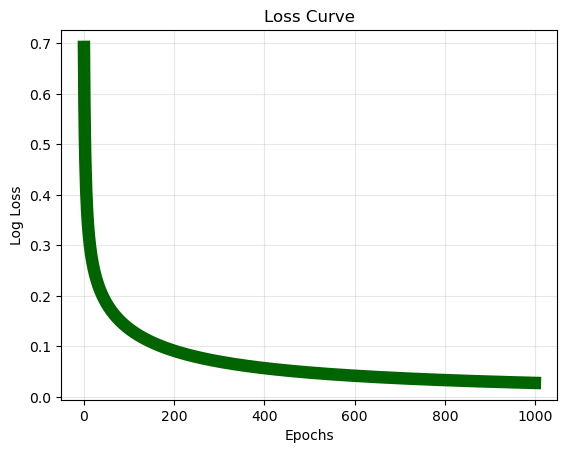

In [30]:
import matplotlib.pyplot as plt

plt.plot(loss_history, color='darkgreen', linewidth=9)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

In [32]:
model=LogisticRegression()

In [33]:
model.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [34]:
model.coef_

array([[ 1.26161576, -0.27665752]])

In [35]:
model.intercept_

array([-4.40181036])

In [38]:
log_loss(y,model.predict_proba(X))

0.10016370477888775

In [40]:
loss_history[-1]

np.float64(0.02754730874048211)